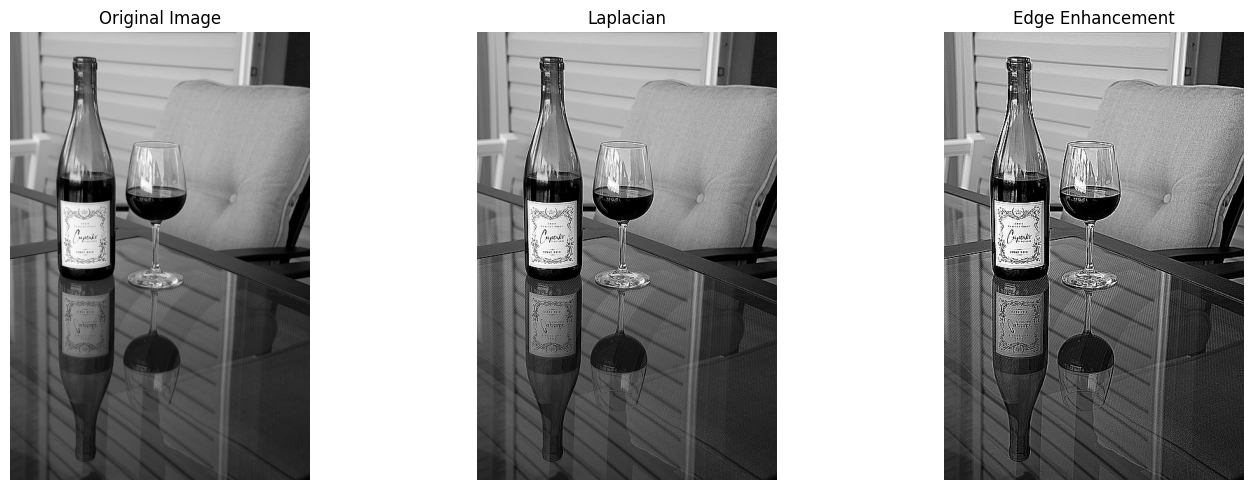

In [26]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def image_sharpening(image_path, kernel_type="laplacian", alpha=0.5):
    """
    Image sharpening using different kernels with original image overlay
    
    Args:
        image_path: Input image path
        kernel_type: Kernel type ("laplacian", "edge_enhance")
        alpha: Sharpening strength coefficient
    
    Returns:
        sharpened: Sharpened image
    """
    # Read image and convert to grayscale
    try:
        img = Image.open(image_path)
        if img.mode != 'L':
            img = img.convert('L')
    except Exception as e:
        print(f"Cannot open image file: {e}")
        return None
    
    # Convert image to numpy array
    img_array = np.array(img, dtype=np.float64)
    height, width = img_array.shape
    
    # Define sharpening kernels
    kernels = {
        "laplacian": np.array([
            [0, -1, 0],
            [-1, 4, -1],
            [0, -1, 0]
        ]),
        
        "edge_enhance": np.array([
            [-1, -1, -1],
            [-1,  8, -1],
            [-1, -1, -1]
        ])
    }
    
    if kernel_type not in kernels:
        print(f"Unsupported kernel type: {kernel_type}")
        return None
    
    kernel = kernels[kernel_type]
    
    # Create output image for edge detection
    edge_result = np.zeros_like(img_array)
    
    # Apply kernel convolution to get edge information
    for i in range(1, height - 1):
        for j in range(1, width - 1):
            region = img_array[i-1:i+2, j-1:j+2]
            edge_result[i, j] = np.sum(region * kernel)
    
    # Overlay with original image using alpha strength
    # sharpened = original + alpha * edge_information
    sharpened = img_array + alpha * edge_result
    
    # Normalize to 0-255 range
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    return sharpened

def display_sharpening_results(image_path, alpha=0.5):
    """
    Display original image and results from two sharpening kernels with overlay
    """
    # Read original image
    try:
        img = Image.open(image_path)
        if img.mode != 'L':
            img = img.convert('L')
    except Exception as e:
        print(f"Cannot open image file: {e}")
        return
    
    img_array = np.array(img)
    
    # Apply two sharpening kernels with overlay
    result_laplacian = image_sharpening(image_path, "laplacian", alpha)
    result_edge_enhance = image_sharpening(image_path, "edge_enhance", alpha)
    
    if result_laplacian is None or result_edge_enhance is None:
        return
    
    # Display three images
    plt.figure(figsize=(15, 5))
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(img_array, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    # Laplacian result with overlay
    plt.subplot(1, 3, 2)
    plt.imshow(result_laplacian, cmap='gray')
    plt.title(f'Laplacian')
    plt.axis('off')
    
    # Edge enhancement result with overlay
    plt.subplot(1, 3, 3)
    plt.imshow(result_edge_enhance, cmap='gray')
    plt.title(f'Edge Enhancement')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return result_laplacian, result_edge_enhance

# Example usage
if __name__ == "__main__":
    import os
    test_image = "test_image.png"
    
    if not os.path.exists(test_image):
        print("Please place an image named 'test_image.png' in the current directory")
        print("Or modify the image path in the code")
        
        # Create a test image if none exists
        print("\nCreating test image...")
        test_img = np.zeros((200, 200), dtype=np.uint8)
        test_img[50:150, 50:150] = 128
        test_img[70:130, 70:130] = 200
        test_img[80:120, 80:120] = 50
        noise = np.random.randint(0, 30, (200, 200))
        test_img = np.clip(test_img + noise, 0, 255).astype(np.uint8)
        Image.fromarray(test_img).save(test_image)
        print(f"Test image created: {test_image}")
    
    # Display results with alpha=0.5
    display_sharpening_results(test_image, alpha=0.5)